# Brace PIC on the openhdemg sample data

This notebook demonstrates the brace-method PIC workflow on the bundled `openhdemg` sample data:

1. Load the sample `openhdemg` data.
2. Convert MU discharge pulses to smoothed discharge-rate traces.
3. Run deterministic `compute_brace_pic(...)` calculations and plot one selected MU.
4. Re-run `compute_brace_pic(...)` with residual bootstrap over the IDR-to-SVR fit (`method="bootstrap_svr"`).
5. Run sensitivity analyses for endpoint placement, endpoint/window averaging, phase fitting, peak-force tolerance, and local SVR smoother settings across all sample MUs.
6. Pool the sensitivity results and fit a Bayesian mixed model to estimate processing-factor and MU effects.

The openhdemg sample is useful for exercising the workflow, but it may not be an ideal triangular-ramp PIC validation trial. Always inspect `result.valid`, `result.exclusion_reasons`, and the plotted geometry before interpreting PIC metrics.

## Interpretation of PIC Metrics following Beauchamp et al. (2023)

## 1. ΔF metrics: paired MU analysis

| Metric | What it measures                                                                                                                                          | Physiological interpretation                                                                                                                                                                                                                                                                                                                              | Benefits                                                                                                                                                                                                                                                                     | Limitations                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| ------ | --------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **ΔF** | The change in discharge rate of a lower-threshold **reporter MU** between recruitment and derecruitment of a higher-threshold **test MU**. Unit: **pps**. | Primarily reflects **PIC prolongation / discharge hysteresis**: the test MU derecruits at a lower estimated synaptic drive than was needed for recruitment. Larger ΔF is generally interpreted as stronger persistent depolarizing current, often linked more closely to slower, persistent CaPIC-mediated hysteresis than to rapid onset amplification.  | Well-established, extensively used, and physiologically intuitive for hysteresis. It directly targets the recruitment–derecruitment mismatch that is a hallmark of PIC prolongation. In repeated matched-MU observations, ΔF showed variability comparable to brace height.  | It is a **paired-unit metric**, so it depends on both the reporter MU and the test MU. Changes cannot be isolated to the test MU alone. It requires suitable lower-threshold reporter units, common-drive criteria, adequate recruitment-time separation, and non-saturated reporter discharge; therefore, it produces fewer valid estimates and is weak for the lowest-threshold MUs. It is also influenced by inhibitory pattern, so ΔF is not a pure neuromodulation measure. |

**Practical interpretation:** ΔF is best read as a **hysteresis/prolongation metric**. A high ΔF suggests stronger persistent depolarizing support after recruitment, but changes in ΔF may reflect **neuromodulation, inhibition, reporter-unit behavior, or their interaction**.

---

## 2. Brace-method metrics: single-MU geometric analysis

The brace method uses the smoothed MU discharge-rate trace plotted against reference force/torque. The paper generated instantaneous discharge rate from MU spike trains, smoothed it with SVR, and evaluated a continuous discharge-rate estimate sampled at 2048 Hz before calculating the metrics. 

| Metric                          | What it measures                                                                                                                                                                                                    | Physiological interpretation                                                                                                                                                                                                                                        | Benefits                                                                                                                                                                                                                                                                                            | Limitations                                                                                                                                                                                                                                                                                                                                                      |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Brace height, BH**            | Maximum **orthogonal deviation** of the smoothed MU discharge-vs-force trace from the straight recruitment-to-peak-discharge line, normalized to the height of the corresponding right triangle. Unit: **% rTri**.  | Index of **PIC amplification** during the ascending ramp. A larger BH means the MU discharge rises more nonlinearly above a passive linear input–output relation, consistent with stronger intrinsic activation by PICs and neuromodulatory drive.                  | Single-MU metric; does not require a reporter MU. In simulations, BH increased consistently with neuromodulation and was comparatively less sensitive to inhibitory pattern, making it useful for separating neuromodulatory from inhibitory effects. It also yielded more valid estimates than ΔF. | Does **not** quantify recruitment–derecruitment hysteresis, so it may miss PIC prolongation that ΔF captures. It may reflect faster NaPIC-related amplification more than slower CaPIC-related hysteresis. It can fail to characterize MUs that peak early and then decline before peak torque; a third post-peak-discharge region may be needed for such units. |
| **Acceleration slope, ACC**     | Slope from recruitment to the brace point. Unit: usually **pps/%MVT**.                                                                                                                                              | Represents the early high-gain “secondary range,” where MU discharge rises steeply after recruitment. Higher ACC is interpreted as faster MU “turn-on,” plausibly reflecting intrinsic PIC-mediated amplification.                                                  | Captures early recruitment dynamics that BH alone compresses into one deviation value. Useful when the early discharge rise itself is of interest.                                                                                                                                                  | More variable than BH and ΔF in repeated observations. It is sensitive to recruitment timing, smoothing, endpoint definition, and the briefness of the acceleration phase. In simulations, its neuromodulation sensitivity was less consistent than BH.                                                                                                          |
| **Attenuation slope, ATT**      | Slope from the brace point to peak discharge. Unit: usually **pps/%MVT**.                                                                                                                                           | Represents the later “tertiary range,” where further increases in force produce attenuated increases in discharge rate. The paper interprets this region as one in which PICs are likely already strongly or fully activated and the MU approaches peak discharge.  | In simulations, ATT was the brace-derived metric most consistently associated with **inhibitory command pattern / excitation–inhibition coupling**. Combined with BH, it may help decouple neuromodulatory drive from inhibitory profile.                                                           | Not a pure PIC-amplitude metric. It depends on rate modulation, peak discharge, and how the brace point is chosen. If ACC and ATT are both high, the discharge profile may be relatively linear despite high slopes, implying less PIC-specific curvature.                                                                                                       |
| **Angle, ANG**                  | Angle between the acceleration and attenuation phases at the brace point. Unit: **degrees**.                                                                                                                        | Shape descriptor of the transition from steep early discharge increase to attenuated later discharge increase. Larger angles generally indicate a stronger bend/nonlinearity in the ascending MU discharge profile.                                                 | Compact descriptor of brace geometry. In matched-MU analysis, angle showed low variability compared with other metrics, though the authors caution that this may partly reflect its high average values.                                                                                            | Physiological specificity is weaker than BH or ATT. It can parallel BH but does not uniquely distinguish neuromodulation from other shape effects. It is also sensitive to axis scaling unless force/torque and discharge-rate units are standardized, e.g. %MVT and pps.                                                                                        |
| **Brace point timing/location** | The force/torque and discharge-rate point at which BH occurs.                                                                                                                                                       | Marks the transition from early high-gain acceleration to later attenuated discharge. Operationally separates secondary and tertiary discharge ranges.                                                                                                              | Useful diagnostic marker for plotting, QC, and segmenting the MU discharge profile.                                                                                                                                                                                                                 | Sensitive to smoothing, noise, sampling, and endpoint choices. Edge brace points or brace points near recruitment/peak are usually unstable and should be inspected.                                                                                                                                                                                             |

## Summary interpretation

**ΔF** mainly indexes **PIC prolongation / hysteresis**, but it is confounded by the reporter MU and by inhibitory pattern. **Brace height** mainly indexes **PIC amplification / neuromodulatory drive** at the single-MU level. **Attenuation slope** appears most useful as an indicator of **inhibitory command pattern**, while **acceleration slope** and **angle** provide additional shape information about early PIC-related turn-on and the transition into attenuated firing. The paper’s central conclusion is that brace height and attenuation slope can complement ΔF by helping separate neuromodulatory drive from excitation–inhibition coupling.


## Setup

Run this notebook from the repository root or from the `notebooks/` directory. The import cell adds `../src` or `src` to `sys.path` so it uses the local checkout.

In [1]:
from __future__ import annotations

import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd
src = repo_root / "src"
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))

try:
    import openhdemg.library as emg
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook uses openhdemg's bundled sample data. Install openhdemg "
        "in the active environment, then rerun this cell."
    ) from exc

from hdsemg_shared.motor_unit.discharge_rate import (
    firing_times_from_indices,
    instantaneous_discharge_rate,
    smooth_discharge_rate_svr,
)
from hdsemg_shared.motor_unit.brace_pic import (
    CIOptions,
    compute_brace_pic,
    plot_brace,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 120

## User-adjustable analysis parameters

`MU_INDICES` controls which sample motor units enter the pooled analysis. The bundled sample currently contains five MUs, so the default uses all available units.

`N_BOOTSTRAP_DRAWS` controls the number of residual-bootstrap-SVR iterations. Lower it during debugging, then restore it before reporting results.

`SMOOTHER_KWARGS` contains the SVR settings used for the deterministic trace and bootstrap-SVR refits. Keep these close to the paper/method settings unless you are explicitly testing smoothing sensitivity.

In [2]:
MU_INDEX = 4
MU_INDICES = None  # None means all sample MUs after the sample file is loaded.

# Evaluation grid for the smoothed discharge-rate trace. A fixed number keeps
# the bootstrap notebook practical while preserving each MU active time span.
N_EVAL = 2048

# SVR smoother settings used to create the input trace for compute_brace_pic.
# These override the shared smooth_discharge_rate_svr defaults and should track
# the paper/method settings being validated.
SMOOTHER_KWARGS = {
    "C": 20.0,
    "gamma": 0.5,
}

# Main brace PIC settings. Every value here is passed to compute_brace_pic.
BRACE_KWARGS = {
    "reference_unit": "%MVC",
    "discharge_unit": "pps",
    "distance_mode": "positive",
    "phase_fit": "endpoints",
    "recruitment_window": 1,
    "peak_window": 1,
    "brace_window": 1,
    "peak_torque_tolerance_s": 0.0,
}

N_BOOTSTRAP_DRAWS = 11_000
RANDOM_STATE = 123
N_JOBS = -1

# Full-factorial sensitivity can be large. Keep None for the full grid, or set
# an integer during development to cap rows per MU.
MAX_SENSITIVITY_ROWS_PER_MU = None

# Bambi model settings for the pooled sensitivity GLMM.
RUN_BAMBI_MODEL = True
BAMBI_CHAINS = 22
BAMBI_CORES = 22
BAMBI_DRAWS = int(N_BOOTSTRAP_DRAWS/(max([BAMBI_CHAINS,BAMBI_CORES])-1)/5)
BAMBI_TUNE = int(N_BOOTSTRAP_DRAWS/1.9)
BAMBI_TARGET_ACCEPT = 0.95
USE_MU_FACTOR_RANDOM_SLOPES = False

print("SVR smoother kwargs:", SMOOTHER_KWARGS)
print("Bootstrap draws:", N_BOOTSTRAP_DRAWS)

SVR smoother kwargs: {'C': 20.0, 'gamma': 0.5}
Bootstrap draws: 11000


## Load openhdemg sample data

`emg_from_samplefile()` returns an example decomposed file with `MUPULSES`, `REF_SIGNAL`, and `FSAMP` fields.

In [3]:
emgfile = emg.emg_from_samplefile()
fsamp = float(emgfile["FSAMP"])
n_mu = int(emgfile["NUMBER_OF_MUS"])
if MU_INDICES is None:
    MU_INDICES = list(range(n_mu))
else:
    MU_INDICES = [int(mu) for mu in MU_INDICES]

print(f"FSAMP: {fsamp:g} Hz")
print(f"Number of MUs: {n_mu}")
print("Analysed MUs:", MU_INDICES)

mu_overview = pd.DataFrame({
    "MU": np.arange(n_mu),
    "n_discharges": [len(np.asarray(p)) for p in emgfile["MUPULSES"]],
    "first_s": [np.asarray(p, dtype=float)[0] / fsamp if len(np.asarray(p)) else np.nan for p in emgfile["MUPULSES"]],
    "last_s": [np.asarray(p, dtype=float)[-1] / fsamp if len(np.asarray(p)) else np.nan for p in emgfile["MUPULSES"]],
})
display(mu_overview)

FSAMP: 2048 Hz
Number of MUs: 5
Analysed MUs: [0, 1, 2, 3, 4]


,MU,n_discharges,first_s,last_s
0,0,137,2.436523,28.846191
1,1,154,4.998047,27.938477
2,2,197,3.448242,28.848145
3,3,293,2.203613,30.137695
4,4,292,2.347656,30.449219


## Build the smoothed discharge-rate trace

`compute_brace_pic(...)` expects a smoothed discharge-rate trace and a reference trace on the same time base. This helper builds those arrays from the openhdemg pulse indices.

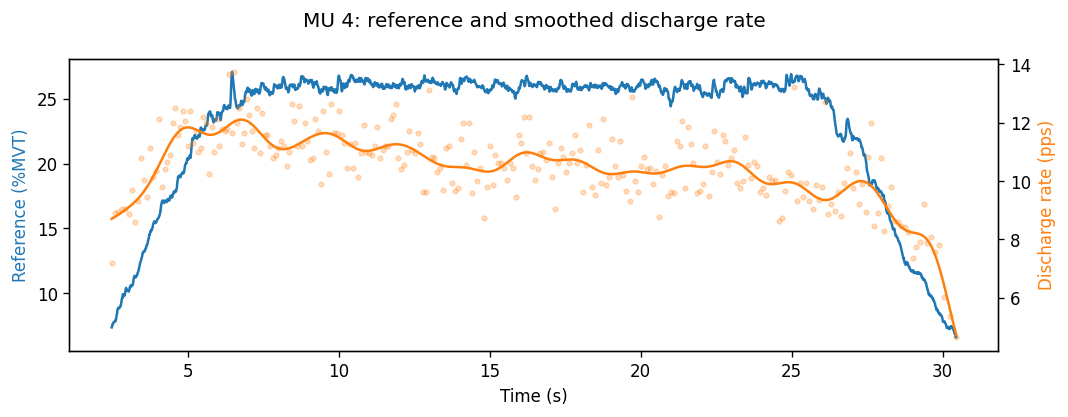

In [4]:
def make_mu_trace(emgfile, mu_index: int, *, n_eval: int, smoother_kwargs: dict):
    fsamp = float(emgfile["FSAMP"])
    ref = emgfile["REF_SIGNAL"].iloc[:, 0].to_numpy(dtype=float)
    pulses = np.asarray(emgfile["MUPULSES"][mu_index], dtype=float)
    if pulses.size < 3:
        raise ValueError(f"MU {mu_index} has too few discharges for an IDR trace.")

    firing_times = firing_times_from_indices(pulses, fsamp)
    rate_times, idr = instantaneous_discharge_rate(firing_times)

    t_eval = np.linspace(rate_times[0], rate_times[-1], int(n_eval))
    _, smooth_rate = smooth_discharge_rate_svr(rate_times, idr, t_eval, **smoother_kwargs)

    ref_time = np.arange(ref.size, dtype=float) / fsamp
    ref_on_rate = np.interp(t_eval, ref_time, ref)
    peak_reference_idx = int(np.nanargmax(ref_on_rate))

    return {
        "mu_index": int(mu_index),
        "pulses": pulses,
        "firing_times": firing_times,
        "rate_times": rate_times,
        "idr": idr,
        "time": t_eval,
        "smooth_rate": np.asarray(smooth_rate, dtype=float),
        "reference": ref_on_rate,
        "peak_reference_idx": peak_reference_idx,
    }

mu_traces = {
    mu: make_mu_trace(emgfile, mu, n_eval=N_EVAL, smoother_kwargs=SMOOTHER_KWARGS)
    for mu in MU_INDICES
}
trace = mu_traces[MU_INDEX]

fig, ax1 = plt.subplots(figsize=(9, 3.5))
ax1.plot(trace["time"], trace["reference"], color="tab:blue", label="reference")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Reference (%MVT)", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(trace["time"], trace["smooth_rate"], color="tab:orange", label="smoothed DR")
ax2.scatter(trace["rate_times"], trace["idr"], s=8, color="tab:orange", alpha=0.25, label="IDR")
ax2.set_ylabel("Discharge rate (pps)", color="tab:orange")
fig.suptitle(f"MU {MU_INDEX}: reference and smoothed discharge rate")
fig.tight_layout()
plt.show()

## Deterministic brace PIC calculation and plot

This cell passes all deterministic geometry options directly to `compute_brace_pic(...)`.

Interpret the geometry and sensitivity outputs as diagnostics, not as a reportable PIC estimate.


,MU,brace_height_norm,brace_height,acceleration_slope,attenuation_slope,angle,valid,exclusion_reasons,recruitment_idx,brace_idx,peak_idx,peak_reference_idx
0,0,14.711995,1.762861,1.109174,0.613115,196.449967,False,peak discharge after peak force/torque,0,100,657,258
1,1,21.465902,0.511495,0.707917,0.288247,199.215870,False,peak discharge after peak force/torque,0,134,472,117
2,2,31.458558,1.391739,0.724225,0.196794,204.779774,False,peak discharge after peak force/torque,0,78,289,229
3,3,23.766826,1.236553,0.384256,0.120578,194.144172,False,peak discharge after peak force/torque,0,165,452,303
4,4,24.926755,0.849086,0.276051,0.073506,191.228197,False,peak discharge after peak force/torque,0,156,314,292


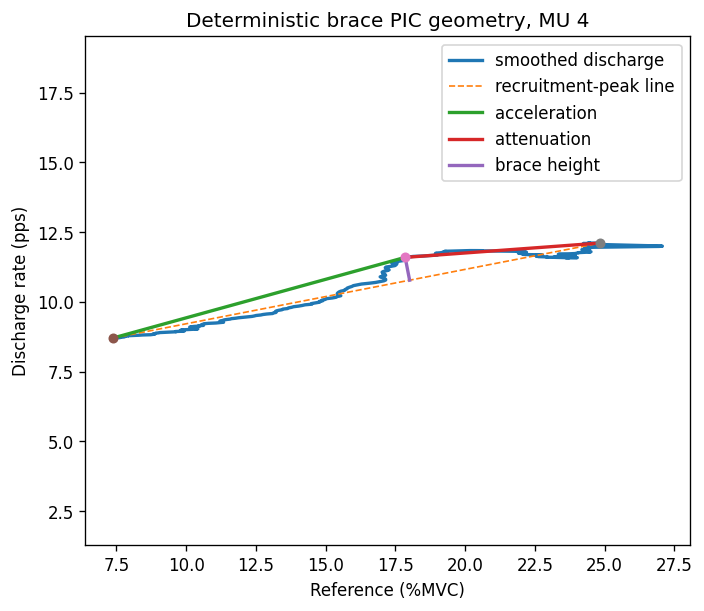

In [5]:
def compute_deterministic_for_trace(trace):
    return compute_brace_pic(
        trace["smooth_rate"],
        trace["reference"],
        fsamp=fsamp,
        time=trace["time"],
        peak_reference_idx=trace["peak_reference_idx"],
        **BRACE_KWARGS,
    )

metric_names = {
    "brace_height_norm": "BH (% rTri)",
    "brace_height": "BH (pps)",
    "acceleration_slope": "ACC (pps/%MVT)",
    "attenuation_slope": "ATT (pps/%MVT)",
    "angle": "Angle (deg)",
}
metric_cols = list(metric_names)

deterministic_by_mu = {mu: compute_deterministic_for_trace(mu_traces[mu]) for mu in MU_INDICES}
deterministic = deterministic_by_mu[MU_INDEX]

if not deterministic.valid:
    print("WARNING: deterministic brace result is invalid:", "; ".join(deterministic.exclusion_reasons))
    print("Interpret the geometry and sensitivity outputs as diagnostics, not as a reportable PIC estimate.")

deterministic_summary = pd.DataFrame([
    {"MU": mu, **res.as_dict(include_ci=False)}
    for mu, res in deterministic_by_mu.items()
])
display(deterministic_summary[[
    "MU", "brace_height_norm", "brace_height", "acceleration_slope",
    "attenuation_slope", "angle", "valid", "exclusion_reasons",
    "recruitment_idx", "brace_idx", "peak_idx", "peak_reference_idx",
]])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_brace(deterministic, ax=ax, title=f"Deterministic brace PIC geometry, MU {MU_INDEX}")
ax.legend(loc="best")
plt.show()

## Bootstrap-SVR HDI estimate

This is the only uncertainty engine used here. It bootstraps centered residuals from the raw IDR-to-SVR regression and returns draw-mean point estimates with HDI intervals.

In [6]:
def bootstrap_options_for_trace(trace, *, seed_offset: int = 0):
    return CIOptions(
        level=95,
        method="bootstrap_svr",
        interval="hdi",
        n_draws=N_BOOTSTRAP_DRAWS,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE + int(seed_offset),
        store_draws=True,
        store_trace_summary=False,
        svr_kwargs=SMOOTHER_KWARGS,
        bootstrap_rate_times=trace["rate_times"],
        bootstrap_rate_values=trace["idr"],
    )


def compute_bootstrap_for_trace(trace, *, seed_offset: int = 0):
    return compute_brace_pic(
        trace["smooth_rate"],
        trace["reference"],
        fsamp=fsamp,
        time=trace["time"],
        peak_reference_idx=trace["peak_reference_idx"],
        ci=95,
        ci_options=bootstrap_options_for_trace(trace, seed_offset=seed_offset),
        **BRACE_KWARGS,
    )

bootstrap_result = compute_bootstrap_for_trace(trace, seed_offset=MU_INDEX)

bootstrap_rows = []
for attr, label in metric_names.items():
    iv = bootstrap_result.ci.intervals[attr]
    deterministic_value = getattr(deterministic, attr)
    bootstrap_rows.append({
        "MU": MU_INDEX,
        "metric": attr,
        "metric_label": label,
        "deterministic": deterministic_value,
        "returned_point_draw_mean": getattr(bootstrap_result, attr),
        "draw_mean": iv.mean,
        "draw_sd": iv.sd,
        "hdi_low": iv.lower,
        "hdi_high": iv.upper,
        "n_finite_draws": iv.n,
        "bias_vs_deterministic": iv.mean - deterministic_value,
        "deterministic_in_hdi": iv.lower <= deterministic_value <= iv.upper,
    })

bootstrap_summary = pd.DataFrame(bootstrap_rows)
display(bootstrap_summary)
print(f"Successful draws: {bootstrap_result.ci.n_successful}/{bootstrap_result.ci.n_requested}; failed: {bootstrap_result.ci.n_failed}")

,MU,metric,metric_label,deterministic,returned_point_draw_mean,draw_mean,draw_sd,hdi_low,hdi_high,n_finite_draws,bias_vs_deterministic,deterministic_in_hdi
0,4,brace_height_norm,BH (% rTri),24.926755,20.314741,20.314741,8.116522,5.650059,34.866529,11000,-4.612014,True
1,4,brace_height,BH (pps),0.849086,0.690130,0.690130,0.301389,0.159423,1.259124,11000,-0.158956,True
2,4,acceleration_slope,ACC (pps/%MVT),0.276051,0.268870,0.268870,0.056733,0.154574,0.364739,10988,-0.007181,True
3,4,attenuation_slope,ATT (pps/%MVT),0.073506,0.085243,0.085243,0.039319,0.013799,0.160772,11000,0.011737,True
4,4,angle,Angle (deg),191.228197,190.146592,190.146592,3.344945,183.251511,196.367174,10988,-1.081606,True


Successful draws: 11000/11000; failed: 0


## Bootstrap and deterministic baselines for all sample MUs

This creates one baseline table per MU and metric. `mode="deterministic"` is the direct brace value; `mode="bootstrap_mean"` is the mean of successful bootstrap draws returned on the result object.

In [7]:
bootstrap_by_mu = {MU_INDEX: bootstrap_result}
for mu in MU_INDICES:
    if mu not in bootstrap_by_mu:
        bootstrap_by_mu[mu] = compute_bootstrap_for_trace(mu_traces[mu], seed_offset=mu)

baseline_rows = []
for mu in MU_INDICES:
    det = deterministic_by_mu[mu]
    boot = bootstrap_by_mu[mu]
    for metric, label in metric_names.items():
        iv = boot.ci.intervals[metric]
        det_value = getattr(det, metric)
        boot_value = getattr(boot, metric)
        baseline_rows.append({
            "MU": str(mu),
            "metric": metric,
            "metric_label": label,
            "mode": "deterministic",
            "value": det_value,
            "draw_sd": np.nan,
            "hdi_low": np.nan,
            "hdi_high": np.nan,
            "baseline_value": det_value,
            "delta": 0.0,
            "abs_delta": 0.0,
            "valid": det.valid,
            "exclusion_reasons": "; ".join(det.exclusion_reasons),
        })
        baseline_rows.append({
            "MU": str(mu),
            "metric": metric,
            "metric_label": label,
            "mode": "bootstrap_mean",
            "value": boot_value,
            "draw_sd": iv.sd,
            "hdi_low": iv.lower,
            "hdi_high": iv.upper,
            "baseline_value": det_value,
            "delta": boot_value - det_value,
            "abs_delta": abs(boot_value - det_value),
            "valid": boot.valid,
            "exclusion_reasons": "; ".join(boot.exclusion_reasons),
        })

baseline_long = pd.DataFrame(baseline_rows)
display(baseline_long)

bootstrap_diagnostics = pd.DataFrame([
    {
        "MU": str(mu),
        "n_requested": bootstrap_by_mu[mu].ci.n_requested,
        "n_successful": bootstrap_by_mu[mu].ci.n_successful,
        "n_failed": bootstrap_by_mu[mu].ci.n_failed,
    }
    for mu in MU_INDICES
])
display(bootstrap_diagnostics)

,MU,metric,metric_label,mode,value,draw_sd,hdi_low,hdi_high,baseline_value,delta,abs_delta,valid,exclusion_reasons
0,0,brace_height_norm,BH (% rTri),deterministic,14.711995,NaN,NaN,NaN,14.711995,0.000000,0.000000,False,peak discharge after peak force/torque
1,0,brace_height_norm,BH (% rTri),bootstrap_mean,13.606695,10.757399,0.000000,32.311401,14.711995,-1.105300,1.105300,False,peak discharge after peak force/torque
2,0,brace_height,BH (pps),deterministic,1.762861,NaN,NaN,NaN,1.762861,0.000000,0.000000,False,peak discharge after peak force/torque
3,0,brace_height,BH (pps),bootstrap_mean,1.724556,1.459850,0.000000,4.446428,1.762861,-0.038305,0.038305,False,peak discharge after peak force/torque
4,0,acceleration_slope,ACC (pps/%MVT),deterministic,1.109174,NaN,NaN,NaN,1.109174,0.000000,0.000000,False,peak discharge after peak force/torque
5,0,acceleration_slope,ACC (pps/%MVT),bootstrap_mean,1.269297,1.888672,-3.412206,2.640252,1.109174,0.160124,0.160124,False,peak discharge after peak force/torque
6,0,attenuation_slope,ATT (pps/%MVT),deterministic,0.613115,NaN,NaN,NaN,0.613115,0.000000,0.000000,False,peak discharge after peak force/torque
7,0,attenuation_slope,ATT (pps/%MVT),bootstrap_mean,0.547477,0.305886,0.003930,0.841593,0.613115,-0.065639,0.065639,False,peak discharge after peak force/torque
8,0,angle,Angle (deg),deterministic,196.449967,NaN,NaN,NaN,196.449967,0.000000,0.000000,False,peak discharge after peak force/torque
9,0,angle,Angle (deg),bootstrap_mean,205.460141,24.501678,180.014349,244.375119,196.449967,9.010174,9.010174,False,peak discharge after peak force/torque


,MU,n_requested,n_successful,n_failed
0,0,11000,10837,163
1,1,11000,10995,5
2,2,11000,11000,0
3,3,11000,11000,0
4,4,11000,11000,0


## Pooled sensitivity analysis across sample MUs

The processing sensitivity grid is evaluated deterministically for every sample MU. The output is stored both in a wide table and a long, model-ready table with one row per `MU x factor x factor_level x metric`.

In [8]:
sensitivity_grid = {
    "recruitment_shift_samples": [0, 5, 20, 50],
    "peak_shift_samples": [0, -5, -20, -50],
    "recruitment_window": [1, 5, 11, 21],
    "peak_window": [1, 5, 11, 21],
    "brace_window": [1, 3, 5, 11],
    "phase_fit": ["endpoints", "ols"],
    "peak_torque_tolerance_s": [0.0, 0.05, 0.10, 0.25],
}

factor_cols = list(sensitivity_grid)
STEP_BY_FACTOR = {
    "recruitment_shift_samples": "endpoint placement",
    "peak_shift_samples": "endpoint placement",
    "recruitment_window": "endpoint/window averaging",
    "peak_window": "endpoint/window averaging",
    "brace_window": "endpoint/window averaging",
    "phase_fit": "phase fitting",
    "peak_torque_tolerance_s": "peak-force timing tolerance",
}


def sensitivity_rows_for_mu(mu: int, base_result, trace, max_rows: int | None = None):
    keys = list(sensitivity_grid)
    combos = itertools.product(*(sensitivity_grid[k] for k in keys))
    for i, values in enumerate(combos):
        if max_rows is not None and i >= max_rows:
            break
        params = dict(zip(keys, values))

        rec_idx = int(base_result.recruitment_idx + params["recruitment_shift_samples"])
        peak_idx = int(base_result.peak_idx + params["peak_shift_samples"])
        rec_idx = max(0, min(rec_idx, len(trace["smooth_rate"]) - 3))
        peak_idx = max(rec_idx + 2, min(peak_idx, len(trace["smooth_rate"]) - 1))

        row_base = {
            "MU": str(mu),
            **params,
            "recruitment_idx": rec_idx,
            "peak_idx": peak_idx,
        }
        try:
            res = compute_brace_pic(
                trace["smooth_rate"],
                trace["reference"],
                fsamp=fsamp,
                time=trace["time"],
                recruitment_idx=rec_idx,
                peak_idx=peak_idx,
                peak_reference_idx=trace["peak_reference_idx"],
                reference_unit=BRACE_KWARGS["reference_unit"],
                discharge_unit=BRACE_KWARGS["discharge_unit"],
                distance_mode=BRACE_KWARGS["distance_mode"],
                phase_fit=params["phase_fit"],
                recruitment_window=params["recruitment_window"],
                peak_window=params["peak_window"],
                brace_window=params["brace_window"],
                peak_torque_tolerance_s=params["peak_torque_tolerance_s"],
            )
            yield {
                **row_base,
                "valid": res.valid,
                "exclusion_reasons": "; ".join(res.exclusion_reasons),
                **{metric: getattr(res, metric) for metric in metric_cols},
            }
        except Exception as exc:
            yield {**row_base, "valid": False, "error": str(exc)}

pooled_sensitivity = pd.DataFrame(
    row
    for mu in MU_INDICES
    for row in sensitivity_rows_for_mu(
        mu,
        deterministic_by_mu[mu],
        mu_traces[mu],
        max_rows=MAX_SENSITIVITY_ROWS_PER_MU,
    )
)
print(f"Sensitivity rows: {len(pooled_sensitivity)}")
display(pooled_sensitivity.head())

sensitivity_long_rows = []
for _, row in pooled_sensitivity.iterrows():
    if not bool(row.get("valid", False)):
        continue
    mu = str(row["MU"])
    for factor in factor_cols:
        factor_level = str(row[factor])
        for metric, label in metric_names.items():
            value = float(row[metric])
            baseline_value = float(getattr(deterministic_by_mu[int(mu)], metric))
            delta = value - baseline_value
            sensitivity_long_rows.append({
                "MU": mu,
                "mode": "deterministic",
                "metric": metric,
                "metric_label": label,
                "processing_step": STEP_BY_FACTOR[factor],
                "factor": factor,
                "factor_level": factor_level,
                "value": value,
                "baseline_value": baseline_value,
                "delta": delta,
                "abs_delta": abs(delta),
                "valid": True,
            })

sensitivity_long = pd.DataFrame(sensitivity_long_rows)
display(sensitivity_long.head())

Sensitivity rows: 40960


,MU,recruitment_shift_samples,peak_shift_samples,recruitment_window,peak_window,brace_window,phase_fit,peak_torque_tolerance_s,recruitment_idx,peak_idx,valid,exclusion_reasons,brace_height_norm,brace_height,acceleration_slope,attenuation_slope,angle
0,0,0,0,1,1,1,endpoints,0.00,0,657,False,peak discharge after peak force/torque,14.711995,1.762861,1.109174,0.613115,196.449967
1,0,0,0,1,1,1,endpoints,0.05,0,657,False,peak discharge after peak force/torque,14.711995,1.762861,1.109174,0.613115,196.449967
2,0,0,0,1,1,1,endpoints,0.10,0,657,False,peak discharge after peak force/torque,14.711995,1.762861,1.109174,0.613115,196.449967
3,0,0,0,1,1,1,endpoints,0.25,0,657,True,,14.711995,1.762861,1.109174,0.613115,196.449967
4,0,0,0,1,1,1,ols,0.00,0,657,False,peak discharge after peak force/torque,14.711995,1.762861,1.072410,-0.039985,196.449967


,MU,mode,metric,metric_label,processing_step,factor,factor_level,value,baseline_value,delta,abs_delta,valid
0,0,deterministic,brace_height_norm,BH (% rTri),endpoint placement,recruitment_shift_samples,0,14.711995,14.711995,0.0,0.0,True
1,0,deterministic,brace_height,BH (pps),endpoint placement,recruitment_shift_samples,0,1.762861,1.762861,0.0,0.0,True
2,0,deterministic,acceleration_slope,ACC (pps/%MVT),endpoint placement,recruitment_shift_samples,0,1.109174,1.109174,0.0,0.0,True
3,0,deterministic,attenuation_slope,ATT (pps/%MVT),endpoint placement,recruitment_shift_samples,0,0.613115,0.613115,0.0,0.0,True
4,0,deterministic,angle,Angle (deg),endpoint placement,recruitment_shift_samples,0,196.449967,196.449967,0.0,0.0,True


### Pooled sensitivity summaries

`relative_to_bootstrap_sd` compares the factor effect to the bootstrap draw SD for the same MU and metric. Values near or above 1 mean the processing-choice effect is as large as, or larger than, bootstrap draw variability.

Valid sensitivity rows: 21426/40960; invalid rows: 19534


brace_height_norm                                                        brace_height                                                   acceleration_slope  \
               count       mean        std        min     median        max        count      mean       std       min    median       max              count   
MU                                                                                                                                                              
0               2048  21.104836   6.429639  12.781833  18.693601  39.968212         2048  1.994925  0.416770  1.166323  1.896042  3.030305               2048   
1               1970  22.331616  10.639249   6.150930  18.747281  66.142473         1970  0.438643  0.160065  0.131611  0.399849  1.021815               1970   
2               6144  34.725943   4.985570  22.113783  34.224764  49.061889         6144  1.176500  0.320021  0.456078  1.318380  1.620624               6144   
3               4608  24.518935   1.073391  21.548557  24.534951  27.593753         4608  1.074852  0.168814  0.687689  1.136623  1.344381               4608   
4               6656  31.889115   5.333104  21.905300  31.946203  45.410902         6656  0.946788  0.096353  0.743315  0.950503  1.184612               6656   

                                                      attenuation_slope                                                   angle                         \
        mean       std       min    median        max             count      mean       std       min    median       max count        mean        std   
MU                                                                                                                                                       
0   1.219366  0.152595  1.033367  1.195880   1.700099              2048  0.209618  0.318384 -0.196317  0.112683  0.627313  2048  204.067708   6.464039   
1   0.652476  0.815314  0.015635  0.378482  19.838786              1970  0.121894  0.219787 -0.182807  0.093281  0.645966  1970  205.277433  19.094157   
2   0.716763  0.126128  0.462256  0.763467   0.930216              6144  0.137610  0.043914  0.048258  0.131018  0.203880  6144  206.515354   4.258212   
3   0.349112  0.027683  0.292783  0.357569   0.384759              4608  0.110845  0.005756  0.103601  0.108789  0.124746  4608  193.336233   1.237233   
4   0.294285  0.024864  0.263701  0.288580   0.352721              6656  0.026210  0.033724 -0.029262  0.021100  0.080561  6656  193.995522   1.962675   

                                        
           min      median         max  
MU                                      
0   194.267860  202.592312  222.183781  
1   186.510428  198.642772  298.409701  
2   194.734034  207.375547  215.680051  
3   190.021494  193.752961  195.129863  
4   190.427346  194.008996  199.020642

,processing_step,factor,metric,metric_label,median_range,max_range,median_relative_to_bootstrap_sd,max_relative_to_bootstrap_sd,n_mu
32,phase fitting,phase_fit,attenuation_slope,ATT (pps/%MVT),0.066761,0.641506,1.501774,2.714494,5
8,endpoint placement,recruitment_shift_samples,brace_height,BH (pps),0.369968,0.740747,1.198057,1.736716,5
4,endpoint placement,peak_shift_samples,brace_height_norm,BH (% rTri),8.483753,14.519146,1.045245,1.349689,5
6,endpoint placement,recruitment_shift_samples,angle,Angle (deg),9.699942,29.720485,0.869808,2.672164,5
2,endpoint placement,peak_shift_samples,attenuation_slope,ATT (pps/%MVT),0.065113,0.232985,0.761673,1.764973,5
9,endpoint placement,recruitment_shift_samples,brace_height_norm,BH (% rTri),5.752279,23.584665,0.730224,2.766266,5
5,endpoint placement,recruitment_shift_samples,acceleration_slope,ACC (pps/%MVT),0.264716,0.328890,0.618413,2.240544,5
3,endpoint placement,peak_shift_samples,brace_height,BH (pps),0.130642,0.912436,0.500961,0.679327,5
1,endpoint placement,peak_shift_samples,angle,Angle (deg),3.458620,12.977054,0.448289,1.033984,5
14,endpoint/window averaging,brace_window,brace_height_norm,BH (% rTri),1.807121,4.634968,0.259780,0.543639,5


,processing_step,factor,metric,metric_label,median_range,max_range,median_relative_to_bootstrap_sd,max_relative_to_bootstrap_sd,n_mu
0,endpoint placement,recruitment_shift_samples,acceleration_slope,ACC (pps/%MVT),0.264716,0.328890,0.618413,2.240544,5
1,phase fitting,phase_fit,acceleration_slope,ACC (pps/%MVT),0.024005,0.375951,0.228591,0.743311,5
2,endpoint/window averaging,recruitment_window,acceleration_slope,ACC (pps/%MVT),0.040087,0.143706,0.066943,0.284129,5
3,endpoint placement,peak_shift_samples,acceleration_slope,ACC (pps/%MVT),0.000000,0.033459,0.000000,0.227937,5
4,endpoint/window averaging,brace_window,acceleration_slope,ACC (pps/%MVT),0.000000,0.040087,0.000000,0.273090,5
5,endpoint placement,recruitment_shift_samples,angle,Angle (deg),9.699942,29.720485,0.869808,2.672164,5
6,endpoint placement,peak_shift_samples,angle,Angle (deg),3.458620,12.977054,0.448289,1.033984,5
7,endpoint/window averaging,brace_window,angle,Angle (deg),1.765784,3.850415,0.241363,0.368491,5
8,endpoint/window averaging,recruitment_window,angle,Angle (deg),1.421748,2.077931,0.154614,0.311015,5
9,endpoint/window averaging,peak_window,angle,Angle (deg),0.563891,1.980932,0.080849,0.168580,5


metric                                                 acceleration_slope     angle  attenuation_slope  brace_height  brace_height_norm
processing_step             factor                                                                                                     
endpoint placement          peak_shift_samples                   0.000000  0.448289           0.761673      0.500961           1.045245
                            recruitment_shift_samples            0.618413  0.869808           0.002299      1.198057           0.730224
endpoint/window averaging   brace_window                         0.000000  0.241363           0.007902      0.194241           0.259780
                            peak_window                          0.000000  0.080849           0.085647      0.084622           0.149003
                            recruitment_window                   0.066943  0.154614           0.000000      0.119876           0.133533
peak-force timing tolerance peak_torque_tolerance_s              0.000000  0.000000           0.000000      0.000000           0.000000
phase fitting               phase_fit                            0.228591  0.000000           1.501774      0.000000           0.000000

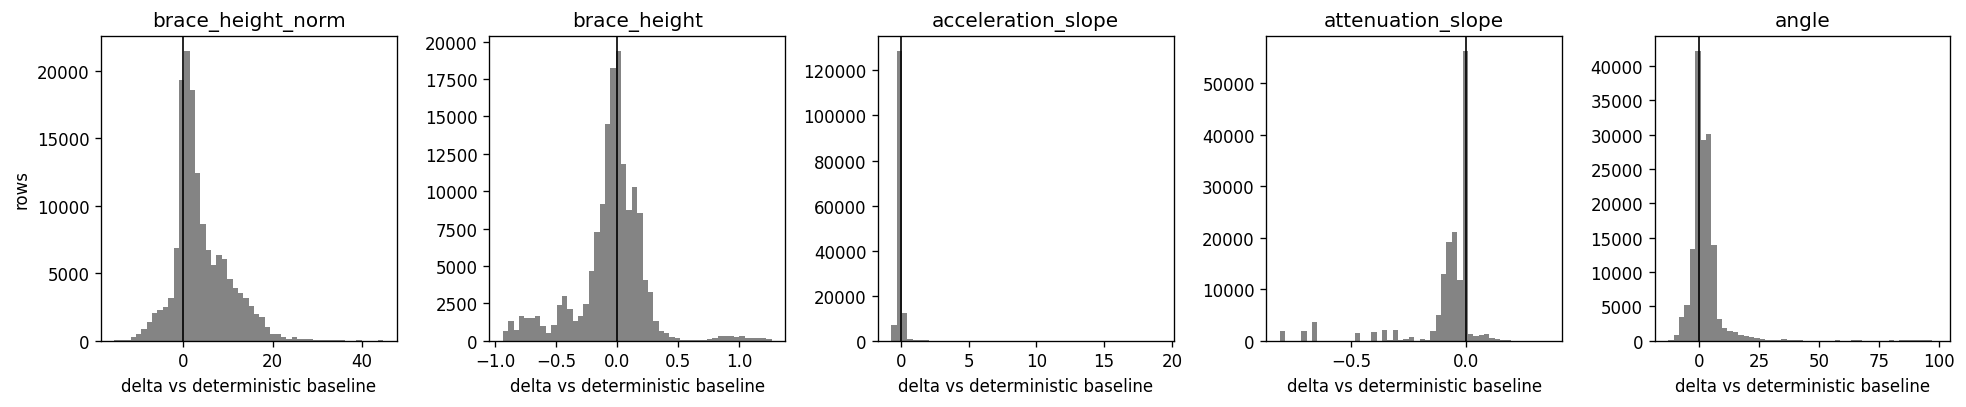

In [9]:
valid_sensitivity = pooled_sensitivity[pooled_sensitivity["valid"]].copy()
invalid_count = len(pooled_sensitivity) - len(valid_sensitivity)
print(f"Valid sensitivity rows: {len(valid_sensitivity)}/{len(pooled_sensitivity)}; invalid rows: {invalid_count}")

overall = valid_sensitivity.groupby("MU")[metric_cols].agg(["count", "mean", "std", "min", "median", "max"])
display(overall)

factor_summaries = []
for mu, mu_df in valid_sensitivity.groupby("MU"):
    mu_int = int(mu)
    for factor in factor_cols:
        grouped = mu_df.groupby(factor, dropna=False)[metric_cols].median()
        ranges = grouped.max() - grouped.min()
        for metric, value in ranges.items():
            boot_sd = bootstrap_by_mu[mu_int].ci.intervals[metric].sd if mu_int in bootstrap_by_mu else np.nan
            factor_summaries.append({
                "MU": str(mu),
                "processing_step": STEP_BY_FACTOR[factor],
                "factor": factor,
                "metric": metric,
                "metric_label": metric_names[metric],
                "range_of_group_medians": value,
                "relative_to_bootstrap_sd": value / boot_sd if boot_sd and np.isfinite(boot_sd) else np.nan,
            })

factor_summary = pd.DataFrame(factor_summaries)
pooled_factor_summary = (
    factor_summary
    .groupby(["processing_step", "factor", "metric", "metric_label"], as_index=False)
    .agg(
        median_range=("range_of_group_medians", "median"),
        max_range=("range_of_group_medians", "max"),
        median_relative_to_bootstrap_sd=("relative_to_bootstrap_sd", "median"),
        max_relative_to_bootstrap_sd=("relative_to_bootstrap_sd", "max"),
        n_mu=("MU", "nunique"),
    )
    .sort_values("median_relative_to_bootstrap_sd", ascending=False)
)
display(pooled_factor_summary)

ranked_by_metric = (
    pooled_factor_summary.sort_values(["metric", "median_relative_to_bootstrap_sd"], ascending=[True, False])
    .groupby("metric", as_index=False)
    .head(5)
    .reset_index(drop=True)
)
display(ranked_by_metric)

pivot = pooled_factor_summary.pivot_table(
    index=["processing_step", "factor"],
    columns="metric",
    values="median_relative_to_bootstrap_sd",
    aggfunc="first",
).fillna(0.0)
display(pivot)

fig, axes = plt.subplots(1, len(metric_cols), figsize=(3.3 * len(metric_cols), 3.5), sharey=False)
for ax, metric in zip(axes, metric_cols):
    data = sensitivity_long[sensitivity_long["metric"] == metric]
    ax.hist(data["delta"].dropna(), bins=50, color="0.4", alpha=0.8)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(metric)
    ax.set_xlabel("delta vs deterministic baseline")
axes[0].set_ylabel("rows")
fig.tight_layout()
plt.show()

### Local SVR smoother sensitivity across sample MUs

This grid evaluates nearby `C`, `gamma`, and `epsilon` settings for every sample MU and appends those effects to the pooled model table.

,MU,C,gamma,epsilon,valid,exclusion_reasons,brace_height_norm,delta_brace_height_norm,brace_height,delta_brace_height,acceleration_slope,delta_acceleration_slope,attenuation_slope,delta_attenuation_slope,angle,delta_angle
11,0,20.0,0.25,0.20,False,peak discharge after peak force/torque,12.390585,-2.321410,1.359551,-0.403311,0.957217,-0.151957,0.581599,-0.031516,193.565519,-2.884448
17,0,20.0,1.00,0.20,False,peak discharge after peak force/torque,12.516556,-2.195438,1.404888,-0.357973,0.979835,-0.129339,0.592305,-0.020810,193.777966,-2.672001
16,0,20.0,1.00,0.10,False,peak discharge after peak force/torque,13.005393,-1.706602,1.484582,-0.278279,0.998138,-0.111036,0.590955,-0.022160,194.365424,-2.084543
15,0,20.0,1.00,0.05,False,peak discharge after peak force/torque,13.417890,-1.294105,1.542743,-0.220118,1.012428,-0.096746,0.589293,-0.023822,194.843275,-1.606692
10,0,20.0,0.25,0.10,False,peak discharge after peak force/torque,13.485127,-1.226867,1.483635,-0.279226,0.985381,-0.123793,0.572374,-0.040741,194.792424,-1.657543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,4,40.0,1.00,0.10,False,peak discharge after peak force/torque,26.737725,1.810969,0.898630,0.049543,0.272720,-0.003331,0.021631,-0.051875,194.015557,2.787360
118,4,20.0,0.25,0.10,False,peak discharge after peak force/torque,27.707351,2.780596,0.858468,0.009382,0.251720,-0.024331,0.059290,-0.014216,190.735897,-0.492300
119,4,20.0,0.25,0.20,True,,27.723817,2.797062,0.915703,0.066617,0.261344,-0.014706,0.066331,-0.007175,190.851428,-0.376769
128,4,40.0,0.25,0.20,False,peak discharge after peak force/torque,28.693723,3.766968,0.957143,0.108057,0.267980,-0.008071,0.062767,-0.010738,191.410061,0.181864


,MU,mode,metric,metric_label,processing_step,factor,factor_level,value,baseline_value,delta,abs_delta,valid
0,0,deterministic,brace_height_norm,BH (% rTri),endpoint placement,recruitment_shift_samples,0,14.711995,14.711995,0.0,0.0,True
1,0,deterministic,brace_height,BH (pps),endpoint placement,recruitment_shift_samples,0,1.762861,1.762861,0.0,0.0,True
2,0,deterministic,acceleration_slope,ACC (pps/%MVT),endpoint placement,recruitment_shift_samples,0,1.109174,1.109174,0.0,0.0,True
3,0,deterministic,attenuation_slope,ATT (pps/%MVT),endpoint placement,recruitment_shift_samples,0,0.613115,0.613115,0.0,0.0,True
4,0,deterministic,angle,Angle (deg),endpoint placement,recruitment_shift_samples,0,196.449967,196.449967,0.0,0.0,True


,factor,metric,metric_label,median_abs_delta,max_abs_delta,n
4,svr_C,brace_height_norm,BH (% rTri),2.892597,4.742062,4
14,svr_gamma,brace_height_norm,BH (% rTri),2.892597,4.742062,4
9,svr_epsilon,brace_height_norm,BH (% rTri),2.892597,4.742062,4
6,svr_epsilon,angle,Angle (deg),1.571066,2.100600,4
11,svr_gamma,angle,Angle (deg),1.571066,2.100600,4
1,svr_C,angle,Angle (deg),1.571066,2.100600,4
3,svr_C,brace_height,BH (pps),0.152481,0.197576,4
13,svr_gamma,brace_height,BH (pps),0.152481,0.197576,4
8,svr_epsilon,brace_height,BH (pps),0.152481,0.197576,4
0,svr_C,acceleration_slope,ACC (pps/%MVT),0.021767,0.038242,4


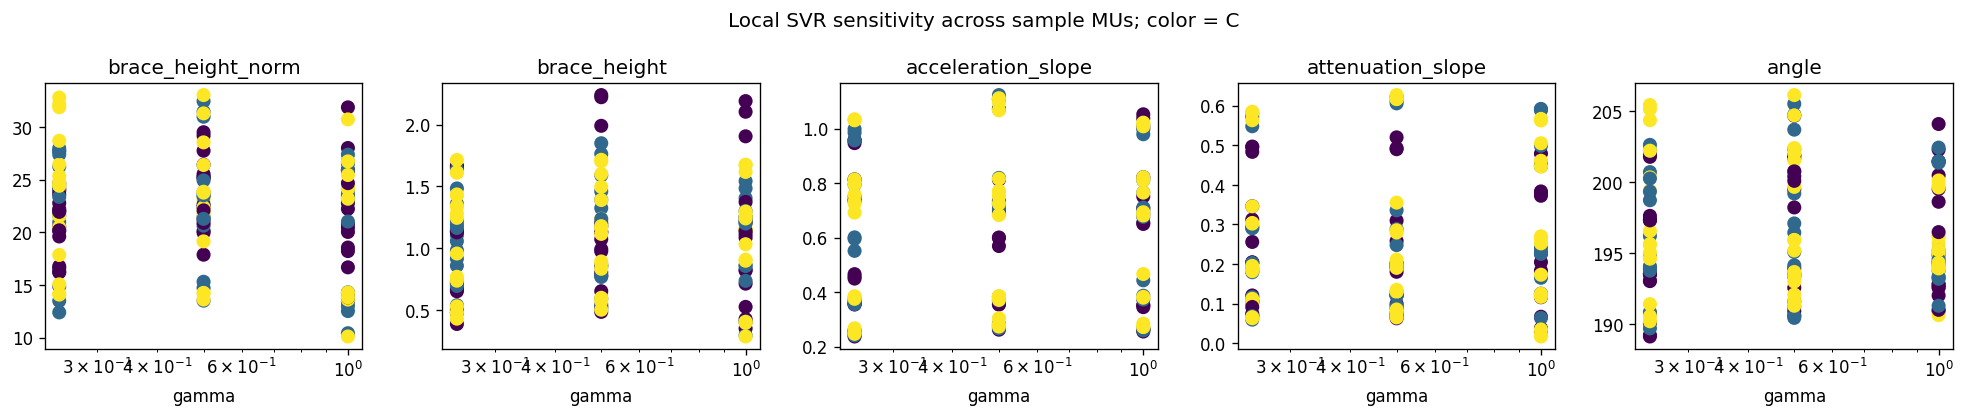

In [10]:
base_svr = {
    "C": float(SMOOTHER_KWARGS.get("C", 10.0)),
    "gamma": float(SMOOTHER_KWARGS.get("gamma", 0.5)),
    "epsilon": float(SMOOTHER_KWARGS.get("epsilon", 0.1)),
    "kernel": SMOOTHER_KWARGS.get("kernel", "rbf"),
}
svr_grid = {
    "C": sorted({max(base_svr["C"] / 2, 1e-9), base_svr["C"], base_svr["C"] * 2}),
    "gamma": sorted({max(base_svr["gamma"] / 2, 1e-9), base_svr["gamma"], base_svr["gamma"] * 2}),
    "epsilon": sorted({max(base_svr["epsilon"] / 2, 1e-9), base_svr["epsilon"], base_svr["epsilon"] * 2}),
}

svr_rows = []
for mu in MU_INDICES:
    trace_mu = mu_traces[mu]
    det_mu = deterministic_by_mu[mu]
    for C, gamma, epsilon in itertools.product(svr_grid["C"], svr_grid["gamma"], svr_grid["epsilon"]):
        kwargs = {"C": C, "gamma": gamma, "epsilon": epsilon, "kernel": base_svr["kernel"]}
        _, smooth = smooth_discharge_rate_svr(trace_mu["rate_times"], trace_mu["idr"], trace_mu["time"], **kwargs)
        res = compute_brace_pic(
            smooth,
            trace_mu["reference"],
            fsamp=fsamp,
            time=trace_mu["time"],
            peak_reference_idx=trace_mu["peak_reference_idx"],
            **BRACE_KWARGS,
        )
        row = {
            "MU": str(mu),
            "C": C,
            "gamma": gamma,
            "epsilon": epsilon,
            "valid": res.valid,
            "exclusion_reasons": "; ".join(res.exclusion_reasons),
        }
        for metric in metric_cols:
            row[metric] = getattr(res, metric)
            row[f"delta_{metric}"] = getattr(res, metric) - getattr(det_mu, metric)
        svr_rows.append(row)

svr_sensitivity = pd.DataFrame(svr_rows)
display(svr_sensitivity.sort_values(["MU", "brace_height_norm"]))

svr_long_rows = []
for _, row in svr_sensitivity[svr_sensitivity["valid"]].iterrows():
    mu = str(row["MU"])
    for param in ["C", "gamma", "epsilon"]:
        for metric, label in metric_names.items():
            value = float(row[metric])
            baseline_value = float(getattr(deterministic_by_mu[int(mu)], metric))
            delta = value - baseline_value
            svr_long_rows.append({
                "MU": mu,
                "mode": "deterministic",
                "metric": metric,
                "metric_label": label,
                "processing_step": "SVR smoothing",
                "factor": f"svr_{param}",
                "factor_level": str(row[param]),
                "value": value,
                "baseline_value": baseline_value,
                "delta": delta,
                "abs_delta": abs(delta),
                "valid": True,
            })

svr_long = pd.DataFrame(svr_long_rows)
model_sensitivity_long = pd.concat([sensitivity_long, svr_long], ignore_index=True)
display(model_sensitivity_long.head())

svr_effect_summary = (
    svr_long.groupby(["factor", "metric", "metric_label"], as_index=False)
    .agg(median_abs_delta=("abs_delta", "median"), max_abs_delta=("abs_delta", "max"), n=("abs_delta", "size"))
    .sort_values("median_abs_delta", ascending=False)
)
display(svr_effect_summary)

fig, axes = plt.subplots(1, len(metric_cols), figsize=(3.3 * len(metric_cols), 3.5))
for ax, metric in zip(axes, metric_cols):
    ax.scatter(svr_sensitivity["gamma"], svr_sensitivity[metric], c=svr_sensitivity["C"], s=55, cmap="viridis")
    ax.set_xscale("log")
    ax.set_xlabel("gamma")
    ax.set_title(metric)
fig.suptitle("Local SVR sensitivity across sample MUs; color = C")
fig.tight_layout()
plt.show()

## Bayesian mixed model for pooled sensitivity

The model response is `log_abs_delta_scaled`, a metric-normalized absolute change from each MU's deterministic baseline. This makes slopes, angles, and brace heights comparable in one model. The default model estimates processing-factor effects while allowing an MU-specific random intercept. Set `USE_MU_FACTOR_RANDOM_SLOPES = True` only if the dataset is large enough for stable factor-by-MU deviations.

In [ ]:
glmm_rows = model_sensitivity_long.copy()

# Add the bootstrap-vs-deterministic estimator difference as an explicit mode.
bootstrap_effect_rows = []
for _, row in baseline_long[baseline_long["mode"] == "bootstrap_mean"].iterrows():
    bootstrap_effect_rows.append({
        "MU": str(row["MU"]),
        "mode": "bootstrap_mean",
        "metric": row["metric"],
        "metric_label": row["metric_label"],
        "processing_step": "estimator uncertainty",
        "factor": "bootstrap_estimator",
        "factor_level": "bootstrap_mean_vs_deterministic",
        "value": float(row["value"]),
        "baseline_value": float(row["baseline_value"]),
        "delta": float(row["delta"]),
        "abs_delta": float(row["abs_delta"]),
        "valid": bool(row["valid"]),
    })

glmm_data = pd.concat([glmm_rows, pd.DataFrame(bootstrap_effect_rows)], ignore_index=True)
glmm_data = glmm_data[np.isfinite(glmm_data["abs_delta"])].copy()
glmm_data["pic_metric"] = glmm_data["metric"]

scale_by_metric = (
    glmm_data.groupby("metric")["abs_delta"]
    .apply(lambda s: float(np.nanmedian(s[s > 0])) if np.any(s > 0) else 1.0)
    .replace(0.0, 1.0)
)
glmm_data["metric_scale"] = glmm_data["metric"].map(scale_by_metric).astype(float)
glmm_data["abs_delta_scaled"] = glmm_data["abs_delta"] / glmm_data["metric_scale"]
glmm_data["log_abs_delta_scaled"] = np.log1p(glmm_data["abs_delta_scaled"])

for col in ["MU", "mode", "pic_metric", "factor", "factor_level", "processing_step"]:
    glmm_data[col] = glmm_data[col].astype("category")

display(glmm_data.head())
display(glmm_data.groupby(["mode", "pic_metric", "factor"], observed=True).size().rename("n").reset_index())

if USE_MU_FACTOR_RANDOM_SLOPES:
    glmm_formula = "log_abs_delta_scaled ~ 0 + mode + pic_metric * factor + (1 + factor|MU)"
else:
    glmm_formula = "log_abs_delta_scaled ~ 0 + mode + pic_metric * factor + (1|MU)"

print("Bambi formula:", glmm_formula)

if RUN_BAMBI_MODEL:
    import arviz as az
    import bambi as bmb

    sensitivity_model = bmb.Model(
        glmm_formula,
        glmm_data,
        family="gaussian",
        categorical=["MU", "mode", "pic_metric", "factor"],
    )
    sensitivity_idata = sensitivity_model.fit(
        draws=BAMBI_DRAWS,
        tune=BAMBI_TUNE,
        chains=BAMBI_CHAINS,
        cores=BAMBI_CORES,
        target_accept=BAMBI_TARGET_ACCEPT,
        random_seed=RANDOM_STATE,
    )
    sensitivity_summary = az.summary(sensitivity_idata, kind="stats")
    display(sensitivity_summary)

    common_effects = sensitivity_summary.loc[
        [idx for idx in sensitivity_summary.index if "|MU" not in idx],
        ["mean", "sd", "hdi_3%", "hdi_97%"],
    ].sort_values("mean", ascending=False)
    display(common_effects.head(30))
else:
    sensitivity_model = None
    sensitivity_idata = None
    print("Set RUN_BAMBI_MODEL = True to fit the Bambi GLMM.")

 Progress                        Draw   Divergences   Step size   Grad evals   Speed         Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   117    0             0.000       31           5.01 s/draw   0:09:46   12:06:32   
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   105    0             0.000       255          5.31 s/draw   0:09:46   -:--:--    
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   108    0             0.000       255          5.05 s/draw   0:09:46   -:--:--    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   86     0             0.000       31           6.77 s/draw   0:09:46   11:59:20   
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   109    0             0.000       255          5.20 s/draw   0:09:46   -:--:--    
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   103    0             0.000       63           5.15 s/draw   0:09:46   18:22:57   
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   109    0             0.000       127          5.26 s/draw   0:09:46   -:--:--    
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   189    0             0.002       7            3.03 s/draw   0:09:46   5:35:43    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   60     0             0.000       63           9.69 s/draw   0:09:46   18:47:05   
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   110    0             0.000       127          5.33 s/draw   0:09:46   -:--:--    
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   107    0             0.000       255          5.19 s/draw   0:09:46   -:--:--    
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   106    0             0.000       255          5.12 s/draw   0:09:46   -:--:--    
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   115    0             0.000       63           5.05 s/draw   0:09:46   23:41:56   
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   85     0             0.000       63           6.88 s/draw   0:09:46   17:19:53   
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   128    0             0.001       15           4.56 s/draw   0:09:46   7:39:10    
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   109    0             0.000       255          5.23 s/draw   0:09:46   -:--:--    
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   108    0             0.000       127          5.42 s/draw   0:09:46   48:12:30   
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   73     0             0.000       63           7.89 s/draw   0:09:46   23:18:10   
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   107    0             0.000       255          5.13 s/draw   0:09:46   -:--:--    
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   107    0             0.000       255          5.33 s/draw   0:09:46   -:--:--    
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   104    0             0.000       255          5.41 s/draw   0:09:46   -:--:--    
  ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━   107    0             0.000       255          5.22 s/draw   0:09:46   -:--:--

## Suggested interpretation checklist

- Check validity flags for every MU before interpreting pooled results.
- Confirm bootstrap HDIs contain the deterministic estimate when reporting the deterministic estimator.
- Treat `factor_summary` and `pooled_factor_summary` as processing-sensitivity diagnostics.
- In the Bambi model, inspect R-hat, ESS, and posterior intervals before ranking factors.
- Large `1|MU` variation means sensitivity depends on the motor unit, not only on the processing factor.
- Report `SMOOTHER_KWARGS`, `N_BOOTSTRAP_DRAWS`, valid-row counts, and the Bambi formula with any results.